In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Covid Data.csv")

In [3]:
df

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03-05-2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03-06-2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09-06-2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12-06-2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21-06-2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2,13,2,1,9999-99-99,97,2,40,97,2,...,2,2,2,2,2,2,2,2,7,97
1048571,1,13,2,2,9999-99-99,2,2,51,97,2,...,2,2,1,2,2,2,2,2,7,2
1048572,2,13,2,1,9999-99-99,97,2,55,97,2,...,2,2,2,2,2,2,2,2,7,97
1048573,2,13,2,1,9999-99-99,97,2,28,97,2,...,2,2,2,2,2,2,2,2,7,97


In [4]:
pd.set_option('display.max_columns', None)

- sex: 1 for female and 2 for male.
- age: of the patient.
- classification: covid test findings. Values 1–3 mean that the patient was diagnosed with covid in different degrees. Values 4   or higher mean that the patient is not a carrier of covid or that the test is inconclusive.
- patient type: type of care the patient received in the unit. 1 for returned home and 2 for hospitalization.
- pneumonia: whether the patient already has air sac inflammation or not.
- pregnancy: whether the patient is pregnant or not.
- diabetes: whether the patient has diabetes or not.
- copd: indicates whether the patient has chronic obstructive pulmonary disease or not.
- asthma: whether the patient has asthma or not.
- inmsupr: whether the patient is immunosuppressed or not.
- hypertension: whether the patient has hypertension or not.
- cardiovascular: whether the patient has heart- or blood-vessel-related disease.
- renal chronic: whether the patient has chronic renal disease or not.
- other disease: whether the patient has any other disease or not.
- obesity: whether the patient is obese or not.
- tobacco: whether the patient is a tobacco user or not.
- usmr: indicates whether the patient was treated in first-, second-, or third-level medical units.
- medical unit: type of institution of the National Health System that provided the care.
- intubed: whether the patient was connected to a ventilator or not.
- icu: indicates whether the patient had been admitted to an Intensive Care Unit.
- date died: if the patient died, the date of death is recorded; otherwise, 9999-99-99 is used.

- Note: 1 = Yes, 2 = No, and 97/99 represent missing or unknown data.

In [5]:
df

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03-05-2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03-06-2020,97,1,72,97,2,2,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09-06-2020,1,2,55,97,1,2,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12-06-2020,97,2,53,2,2,2,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21-06-2020,97,2,68,97,1,2,2,2,1,2,2,2,2,2,3,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2,13,2,1,9999-99-99,97,2,40,97,2,2,2,2,2,2,2,2,2,2,7,97
1048571,1,13,2,2,9999-99-99,2,2,51,97,2,2,2,2,1,2,2,2,2,2,7,2
1048572,2,13,2,1,9999-99-99,97,2,55,97,2,2,2,2,2,2,2,2,2,2,7,97
1048573,2,13,2,1,9999-99-99,97,2,28,97,2,2,2,2,2,2,2,2,2,2,7,97


In [6]:
def eda_report(df):

    print('='*60)
    print('DATASET SHAPE')
    print(df.shape)

    print('\n'+'='*60)
    print('DUPLICATES')
    print(df.duplicated().sum())
    
    print('\n' + '='*60)
    print('DATA TYPES')
    display(df.dtypes)

    
    print('\n'+'='*60)
    print('MISSING VALUES')
    display(
        pd.DataFrame({
            'Null Count':df.isnull().sum(),
            'Null %':round(df.isnull().mean()*100,2)
        }).sort_values('Null %',ascending=False)
    )

    print('\n'+'='*60)
    print('NUMERICAL SUMMARY')
    display(df.describe())

    print('\n'+'='*60)
    print('CATEGORICAL SUMMARY')
    display(df.describe(include='object'))

In [7]:
eda_report(df)


DATASET SHAPE
(1048575, 21)

DUPLICATES
812049

DATA TYPES


USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU                      int64
dtype: object


MISSING VALUES


,Null Count,Null %
USMER,0,0.0
ASTHMA,0,0.0
CLASIFFICATION_FINAL,0,0.0
TOBACCO,0,0.0
RENAL_CHRONIC,0,0.0
OBESITY,0,0.0
CARDIOVASCULAR,0,0.0
OTHER_DISEASE,0,0.0
HIPERTENSION,0,0.0
INMSUPR,0,0.0



NUMERICAL SUMMARY


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01



CATEGORICAL SUMMARY


,DATE_DIED
count,1048575
unique,401
top,9999-99-99
freq,971633


# Feature Engineering

In [8]:
df['DATE_DIED'].value_counts()

9999-99-99    971633
06-07-2020      1000
07-07-2020       996
13-07-2020       990
16-06-2020       979
               ...  
24-11-2020         1
17-12-2020         1
08-12-2020         1
16-03-2021         1
22-04-2021         1
Name: DATE_DIED, Length: 401, dtype: int64

In [9]:
df['Death'] = np.where(df['DATE_DIED']=='9999-99-99',0,1)

In [10]:
df['Death'].value_counts()

0    971633
1     76942
Name: Death, dtype: int64

In [11]:
df['SEX'] = df['SEX'].replace({1:'Female', 2:'Male'})

In [12]:
df

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death
0,2,1,Female,1,03-05-2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,3,97,1
1,2,1,Male,1,03-06-2020,97,1,72,97,2,2,2,2,1,2,2,1,1,2,5,97,1
2,2,1,Male,2,09-06-2020,1,2,55,97,1,2,2,2,2,2,2,2,2,2,3,2,1
3,2,1,Female,1,12-06-2020,97,2,53,2,2,2,2,2,2,2,2,2,2,2,7,97,1
4,2,1,Male,1,21-06-2020,97,2,68,97,1,2,2,2,1,2,2,2,2,2,3,97,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2,13,Male,1,9999-99-99,97,2,40,97,2,2,2,2,2,2,2,2,2,2,7,97,0
1048571,1,13,Male,2,9999-99-99,2,2,51,97,2,2,2,2,1,2,2,2,2,2,7,2,0
1048572,2,13,Male,1,9999-99-99,97,2,55,97,2,2,2,2,2,2,2,2,2,2,7,97,0
1048573,2,13,Male,1,9999-99-99,97,2,28,97,2,2,2,2,2,2,2,2,2,2,7,97,0


In [13]:
bins = [0,2,12,19,30,60,121]
labels = ['Infants','Children','Teens','Young Adults','Adults','Seniors']
df['Age_Group'] = pd.cut(df['AGE'],bins=bins,labels=labels,include_lowest=True)

In [14]:
df['Age_Group'].value_counts()

Adults          623016
Young Adults    213511
Seniors         144372
Teens            31203
Children         24631
Infants          11842
Name: Age_Group, dtype: int64

In [15]:
df['CLASIFFICATION_FINAL'].value_counts()

7    499250
3    381527
6    128133
5     26091
1      8601
4      3122
2      1851
Name: CLASIFFICATION_FINAL, dtype: int64

In [16]:
df['COVID_Positive'] = np.where(
    df['CLASIFFICATION_FINAL'] <= 3,
    1,
    0
)

In [17]:
df

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death,Age_Group,COVID_Positive
0,2,1,Female,1,03-05-2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,3,97,1,Seniors,1
1,2,1,Male,1,03-06-2020,97,1,72,97,2,2,2,2,1,2,2,1,1,2,5,97,1,Seniors,0
2,2,1,Male,2,09-06-2020,1,2,55,97,1,2,2,2,2,2,2,2,2,2,3,2,1,Adults,1
3,2,1,Female,1,12-06-2020,97,2,53,2,2,2,2,2,2,2,2,2,2,2,7,97,1,Adults,0
4,2,1,Male,1,21-06-2020,97,2,68,97,1,2,2,2,1,2,2,2,2,2,3,97,1,Seniors,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2,13,Male,1,9999-99-99,97,2,40,97,2,2,2,2,2,2,2,2,2,2,7,97,0,Adults,0
1048571,1,13,Male,2,9999-99-99,2,2,51,97,2,2,2,2,1,2,2,2,2,2,7,2,0,Adults,0
1048572,2,13,Male,1,9999-99-99,97,2,55,97,2,2,2,2,2,2,2,2,2,2,7,97,0,Adults,0
1048573,2,13,Male,1,9999-99-99,97,2,28,97,2,2,2,2,2,2,2,2,2,2,7,97,0,Young Adults,0


In [18]:
df['COVID_Positive'].value_counts()

0    656596
1    391979
Name: COVID_Positive, dtype: int64

In [19]:
df['PATIENT_TYPE'].value_counts()

1    848544
2    200031
Name: PATIENT_TYPE, dtype: int64

In [20]:
df['Hospitalized'] = df['PATIENT_TYPE'].replace({1:0,2:1})

In [21]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death,Age_Group,COVID_Positive,Hospitalized
0,2,1,Female,1,03-05-2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,3,97,1,Seniors,1,0
1,2,1,Male,1,03-06-2020,97,1,72,97,2,2,2,2,1,2,2,1,1,2,5,97,1,Seniors,0,0
2,2,1,Male,2,09-06-2020,1,2,55,97,1,2,2,2,2,2,2,2,2,2,3,2,1,Adults,1,1
3,2,1,Female,1,12-06-2020,97,2,53,2,2,2,2,2,2,2,2,2,2,2,7,97,1,Adults,0,0
4,2,1,Male,1,21-06-2020,97,2,68,97,1,2,2,2,1,2,2,2,2,2,3,97,1,Seniors,1,0


In [22]:
df['Hospitalized'].value_counts()

0    848544
1    200031
Name: Hospitalized, dtype: int64

In [23]:
df

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death,Age_Group,COVID_Positive,Hospitalized
0,2,1,Female,1,03-05-2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,3,97,1,Seniors,1,0
1,2,1,Male,1,03-06-2020,97,1,72,97,2,2,2,2,1,2,2,1,1,2,5,97,1,Seniors,0,0
2,2,1,Male,2,09-06-2020,1,2,55,97,1,2,2,2,2,2,2,2,2,2,3,2,1,Adults,1,1
3,2,1,Female,1,12-06-2020,97,2,53,2,2,2,2,2,2,2,2,2,2,2,7,97,1,Adults,0,0
4,2,1,Male,1,21-06-2020,97,2,68,97,1,2,2,2,1,2,2,2,2,2,3,97,1,Seniors,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2,13,Male,1,9999-99-99,97,2,40,97,2,2,2,2,2,2,2,2,2,2,7,97,0,Adults,0,0
1048571,1,13,Male,2,9999-99-99,2,2,51,97,2,2,2,2,1,2,2,2,2,2,7,2,0,Adults,0,1
1048572,2,13,Male,1,9999-99-99,97,2,55,97,2,2,2,2,2,2,2,2,2,2,7,97,0,Adults,0,0
1048573,2,13,Male,1,9999-99-99,97,2,28,97,2,2,2,2,2,2,2,2,2,2,7,97,0,Young Adults,0,0


In [24]:
import numpy as np

# Replacing missing values
replacements = {
    "INTUBED": {97: np.nan, 99: np.nan},
    "PNEUMONIA": {99: np.nan},
    "PREGNANT": {97: np.nan, 98: np.nan},
    "DIABETES": {98: np.nan},
    "COPD": {98: np.nan},
    "ASTHMA": {98: np.nan},
    "INMSUPR": {98: np.nan},
    "HIPERTENSION": {98: np.nan},
    "CARDIOVASCULAR": {98: np.nan},
    "OBESITY": {98: np.nan},
    "RENAL_CHRONIC": {98: np.nan},
    "TOBACCO": {98: np.nan},
    "ICU": {97: np.nan, 99: np.nan},
    "OTHER_DISEASE": {98: np.nan} 
}

# Apply replacements
df.replace(replacements, inplace=True)

# Binary columns
binary_cols = ['INTUBED','PNEUMONIA','DIABETES', 'COPD', 'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
               'OBESITY','RENAL_CHRONIC','TOBACCO','ICU','PREGNANT']


# Convert 1/2 into 1/0
for col in binary_cols:
    df[col] = df[col].replace({1:1, 2:0})

# Check result
print(df[binary_cols].head())

   INTUBED  PNEUMONIA  DIABETES  COPD  ASTHMA  INMSUPR  HIPERTENSION  \
0      NaN        1.0       0.0   0.0     0.0      0.0           1.0   
1      NaN        1.0       0.0   0.0     0.0      0.0           1.0   
2      1.0        0.0       1.0   0.0     0.0      0.0           0.0   
3      NaN        0.0       0.0   0.0     0.0      0.0           0.0   
4      NaN        0.0       1.0   0.0     0.0      0.0           1.0   

   OTHER_DISEASE  CARDIOVASCULAR  OBESITY  RENAL_CHRONIC  TOBACCO  ICU  \
0            0.0             0.0      0.0            0.0      0.0  NaN   
1            0.0             0.0      1.0            1.0      0.0  NaN   
2            0.0             0.0      0.0            0.0      0.0  0.0   
3            0.0             0.0      0.0            0.0      0.0  NaN   
4            0.0             0.0      0.0            0.0      0.0  NaN   

   PREGNANT  
0       0.0  
1       NaN  
2       NaN  
3       0.0  
4       NaN  


In [25]:
df[binary_cols].head()

,INTUBED,PNEUMONIA,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,ICU,PREGNANT
0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
1,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,NaN,NaN
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [26]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death,Age_Group,COVID_Positive,Hospitalized
0,2,1,Female,1,03-05-2020,NaN,1.0,65,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN,1,Seniors,1,0
1,2,1,Male,1,03-06-2020,NaN,1.0,72,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,5,NaN,1,Seniors,0,0
2,2,1,Male,2,09-06-2020,1.0,0.0,55,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,1,Adults,1,1
3,2,1,Female,1,12-06-2020,NaN,0.0,53,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,NaN,1,Adults,0,0
4,2,1,Male,1,21-06-2020,NaN,0.0,68,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN,1,Seniors,1,0


In [27]:
df.isnull().sum()

USMER                        0
MEDICAL_UNIT                 0
SEX                          0
PATIENT_TYPE                 0
DATE_DIED                    0
INTUBED                 855869
PNEUMONIA                16003
AGE                          0
PREGNANT                527265
DIABETES                  3338
COPD                      3003
ASTHMA                    2979
INMSUPR                   3404
HIPERTENSION              3104
OTHER_DISEASE             5045
CARDIOVASCULAR            3076
OBESITY                   3032
RENAL_CHRONIC             3006
TOBACCO                   3220
CLASIFFICATION_FINAL         0
ICU                     856032
Death                        0
Age_Group                    0
COVID_Positive               0
Hospitalized                 0
dtype: int64

In [28]:
df['DATE_DIED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce')

df['Death_Year'] = df['DATE_DIED'].dt.year
df['Death_Month'] = df['DATE_DIED'].dt.month


C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1047: UserWarning: Parsing '21-06-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1047: UserWarning: Parsing '26-02-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1047: UserWarning: Parsing '20-05-2020' in DD/MM/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  cache_array = _maybe_cache(arg, format, cache, convert_listlike)
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\tools\datetimes.py:1047: UserWarning: Parsing '17-07-2020' in DD/MM/YYYY format. Provide format or specif

In [29]:
df['Death_Month_2020'] = np.where(
    df['Death_Year'] == 2020,
    df['DATE_DIED'].dt.month_name(),
    np.nan
)

df['Death_Month_2021'] = np.where(
    df['Death_Year'] == 2021,
    df['DATE_DIED'].dt.month_name(),
    np.nan
)

In [30]:
def create_severity(df):
    df['severity'] = np.where((df['ICU']== 1) | (df['INTUBED']== 1),"Critical","Normal")
    
    return df

In [31]:
create_severity(df).head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,Death,Age_Group,COVID_Positive,Hospitalized,Death_Year,Death_Month,Death_Month_2020,Death_Month_2021,severity
0,2,1,Female,1,2020-03-05,NaN,1.0,65,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN,1,Seniors,1,0,2020.0,3.0,March,NaN,Normal
1,2,1,Male,1,2020-03-06,NaN,1.0,72,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,5,NaN,1,Seniors,0,0,2020.0,3.0,March,NaN,Normal
2,2,1,Male,2,2020-09-06,1.0,0.0,55,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,0.0,1,Adults,1,1,2020.0,9.0,September,NaN,Critical
3,2,1,Female,1,2020-12-06,NaN,0.0,53,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,NaN,1,Adults,0,0,2020.0,12.0,December,NaN,Normal
4,2,1,Male,1,2020-06-21,NaN,0.0,68,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,NaN,1,Seniors,1,0,2020.0,6.0,June,NaN,Normal


In [32]:
disease_mapping = {
    'PNEUMONIA': 1,         
    'DIABETES': 1,               
    'COPD': 1,     
    'ASTHMA': 1,
    'INMSUPR': 1,
    'HIPERTENSION': 1,
    'CARDIOVASCULAR':1,
    'OBESITY': 1,
    'RENAL_CHRONIC':1,
    'OTHER_DISEASE': 1
}

df['TOTAL_DISEASES'] = 0

for col, positive_value in disease_mapping.items():
    df['TOTAL_DISEASES'] += (df[col] == positive_value).astype(int)

# Perform univeriant,bivarient and multivariant on new columns in Covid dataset

## Univariate Analysis

### Distribution of Death Cases

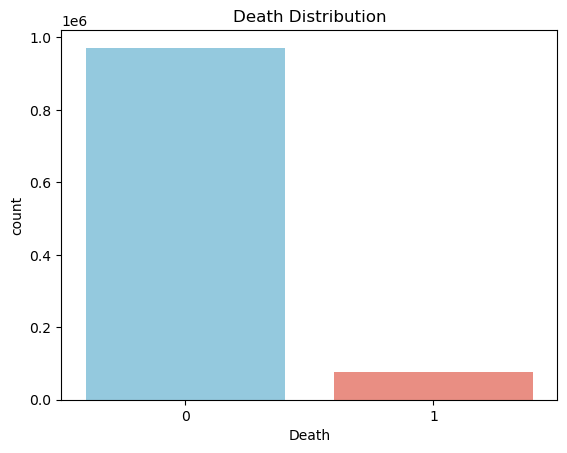

0    971633
1     76942
Name: Death, dtype: int64


In [33]:
sns.countplot(
    x='Death',
    data=df,
    palette=['skyblue', 'salmon']
)

plt.title('Death Distribution')
plt.show()

print(df['Death'].value_counts())

In [34]:
# Conclusion 
# The analysis shows that the majority of COVID-19 patients survived, while only a smaller proportion resulted in death, indicating a relatively low mortality rate in the dataset.

###  Age Group Distribution Analysis

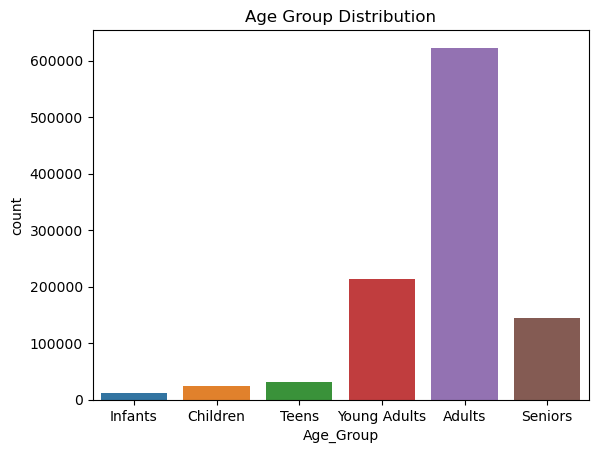

In [35]:
sns.countplot(x="Age_Group",data=df)
plt.title("Age Group Distribution")
plt.show()

In [36]:
# Conclusion
# The dataset contains a higher number of cases in the middle and older age groups, indicating that COVID-19 records are more concentrated among adults and elderly individuals.

### Gender Distribution

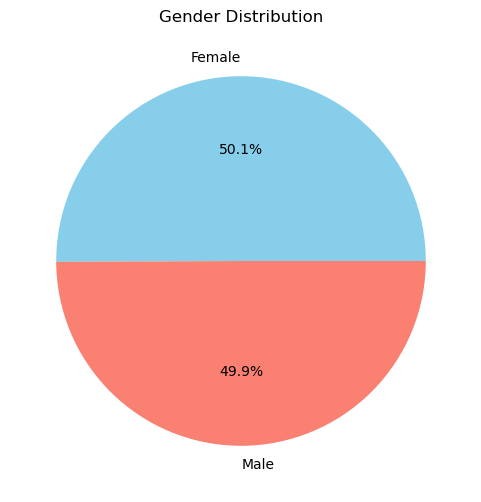

In [37]:
sex_counts = df['SEX'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sex_counts,
    labels=['Female', 'Male'],
    colors=['skyblue', 'salmon'],
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.show()

In [38]:
# Conclusion 
# The gender distribution analysis shows the proportion of male and female patients in the dataset, helping identify the representation of each gender among the recorded COVID-19 cases.

### Asthma Distribution

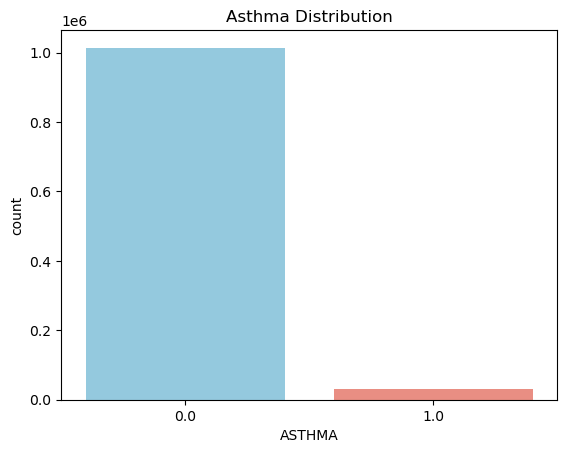

0.0    1014024
1.0      31572
Name: ASTHMA, dtype: int64


In [39]:
sns.countplot(
    x='ASTHMA',
    data=df,
    palette=['skyblue', 'salmon']
)

plt.title('Asthma Distribution')
plt.show()

print(df['ASTHMA'].value_counts())

In [40]:
# Conclusion
# Most patients in the dataset do not have asthma, while only a smaller proportion are reported with asthma.

### COVID Distribution

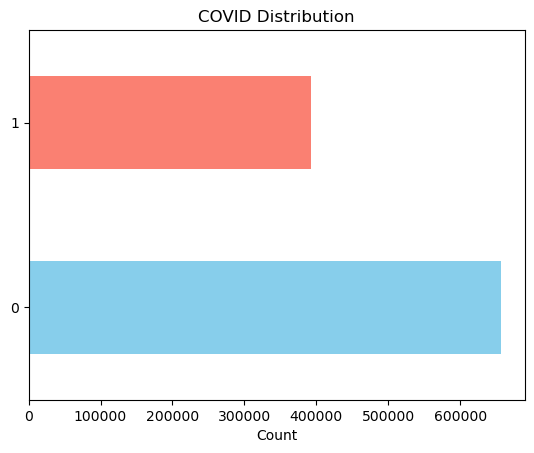

In [41]:
df['COVID_Positive'].value_counts().plot(
    kind='barh',
    color=['skyblue', 'salmon']
)

plt.title('COVID Distribution')
plt.xlabel('Count')
plt.show()

In [42]:
# Conclusion
# The analysis shows that COVID-positive cases are more prevalent in the dataset, indicating that a larger proportion of the recorded patients were confirmed to have COVID-19.

### Hospitalized Distribution

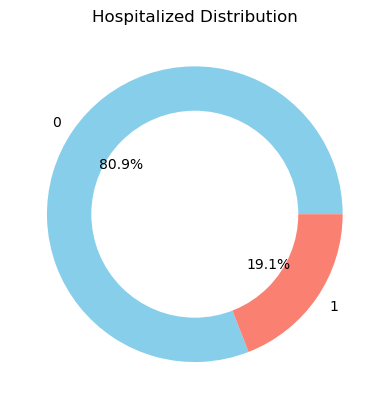

In [43]:
counts = df['Hospitalized'].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    colors=['skyblue', 'salmon'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Hospitalized Distribution')
plt.show()

In [44]:
# Conclusion
# The majority of patients were not hospitalized, while a smaller proportion required hospitalization, indicating that most cases were managed without hospital admission.

# Bivarient Analysis

### Death VS Gender 

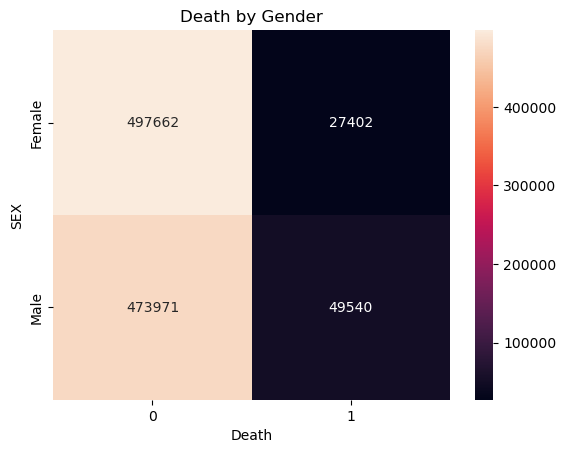

In [45]:
temp = pd.crosstab(df['SEX'], df['Death'])

sns.heatmap(
    temp,
    annot=True,
    fmt='d'
)

plt.title('Death by Gender')
plt.show()

In [46]:
# Conclusion
# The heatmap shows the distribution of deaths across genders, helping identify whether mortality was higher among male or female patients in the dataset.

### COVID-19 Positivity Rate VS Gender

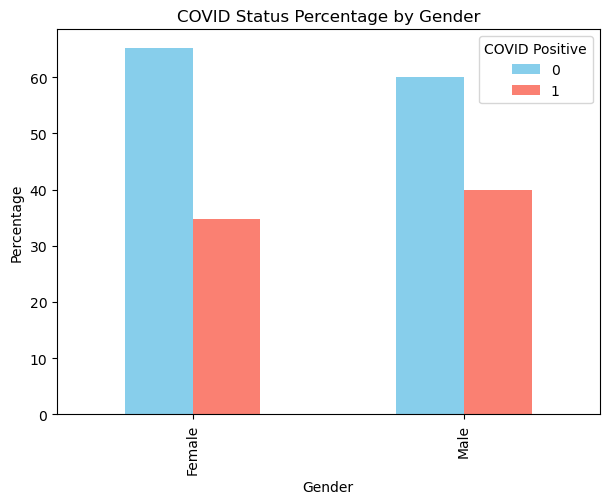

In [47]:
temp = pd.crosstab(
    df['SEX'],
    df['COVID_Positive'],
    normalize='index'
) * 100

temp.plot(
    kind='bar',
    color=['skyblue', 'salmon'],
    figsize=(7,5)
)

plt.title('COVID Status Percentage by Gender')
plt.ylabel('Percentage')
plt.xlabel('Gender')
plt.legend(title='COVID Positive')
plt.show()

In [48]:
# Conclusion
# The percentage distribution of COVID-positive cases varies across genders, allowing comparison of COVID-19 prevalence between male and female patients.

### Age Group vs Death 

COVID_Positive          0          1
SEX                                 
Female          65.244237  34.755763
Male            59.983840  40.016160


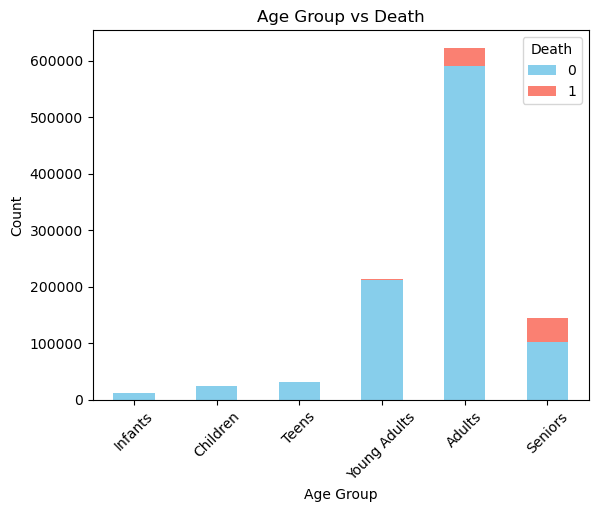

In [49]:
pd.crosstab(
    df['Age_Group'],
    df['Death']
).plot(
    kind='bar',
    color=['skyblue', 'salmon'],
    stacked=True
)
print(temp)
plt.title('Age Group vs Death')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.show()

In [50]:
# Conclusion
# The analysis indicates that death cases are more concentrated in the older age groups, suggesting that mortality risk increases with age among COVID-19 patients.

###  Death Percentage VS Age Group

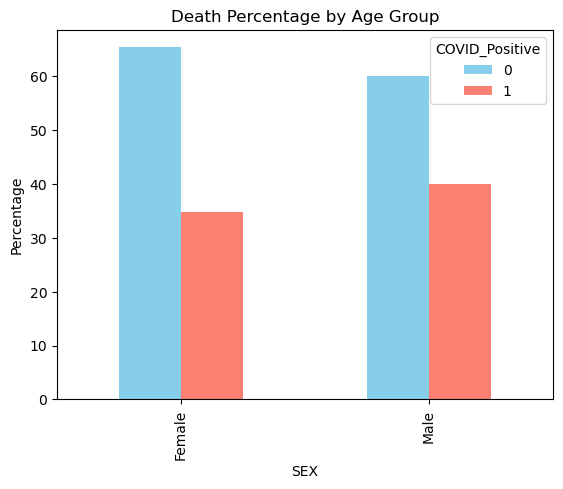

In [51]:
temp.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Death Percentage by Age Group')
plt.ylabel('Percentage')
plt.show()

In [52]:
# Conclusion
# The death percentage increases with age, indicating that older age groups are at a higher risk of mortality from COVID-19.

###  Age Group VS COVID Status

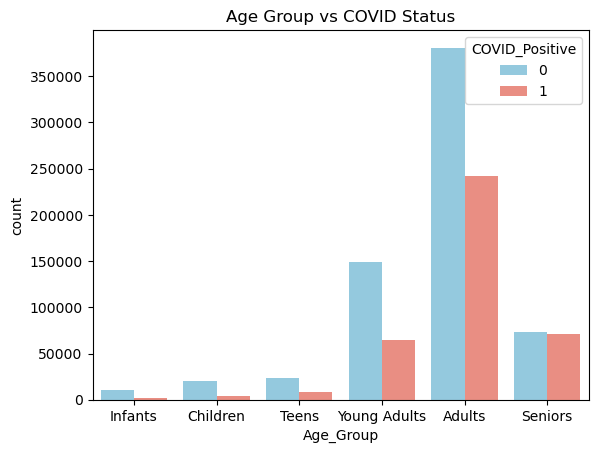

In [53]:
sns.countplot(
    x='Age_Group',
    hue='COVID_Positive',
    data=df,
    palette=['skyblue', 'salmon']
)

plt.title('Age Group vs COVID Status')
plt.show()

In [54]:
# Conclusion
# COVID-19 cases are distributed across all age groups, with some age groups showing a higher number of positive cases than others.

### Age Distribution VS Death

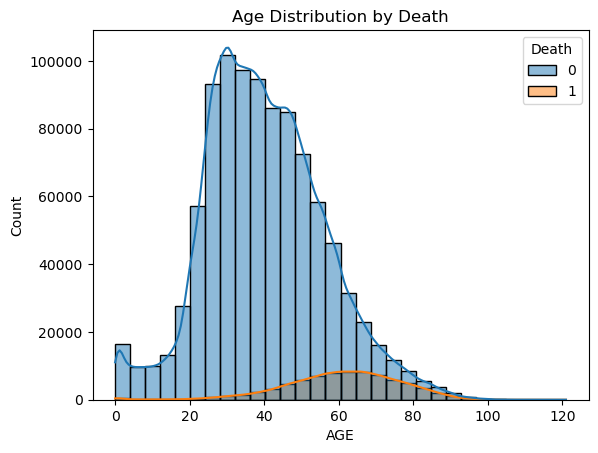

In [55]:
sns.histplot(
    data=df,
    x='AGE',
    hue='Death',
    bins=30,
    kde=True
)

plt.title('Age Distribution by Death')
plt.show()

In [56]:
# Conclusion
# The age distribution indicates that death cases are more common among older patients, while younger age groups show lower mortality.

### Hospitalized VS Death

COVID_Positive          0          1
SEX                                 
Female          65.244237  34.755763
Male            59.983840  40.016160


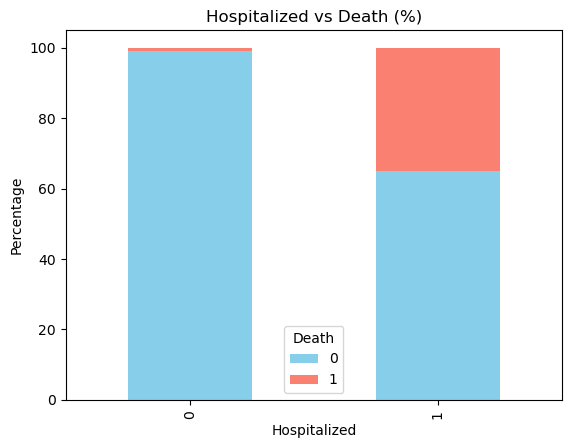

In [57]:
ct = pd.crosstab(
    df['Hospitalized'],
    df['Death'],
    normalize='index'
) * 100

ct.plot(
    kind='bar',
    stacked=True,
    color=['skyblue', 'salmon']
)
print(temp)
plt.title('Hospitalized vs Death (%)')
plt.ylabel('Percentage')
plt.show()

In [58]:
# Conclusion
# Hospitalized patients show a higher death percentage compared to non-hospitalized patients, indicating that severe cases had a greater risk of mortality.

### Disease VS Death

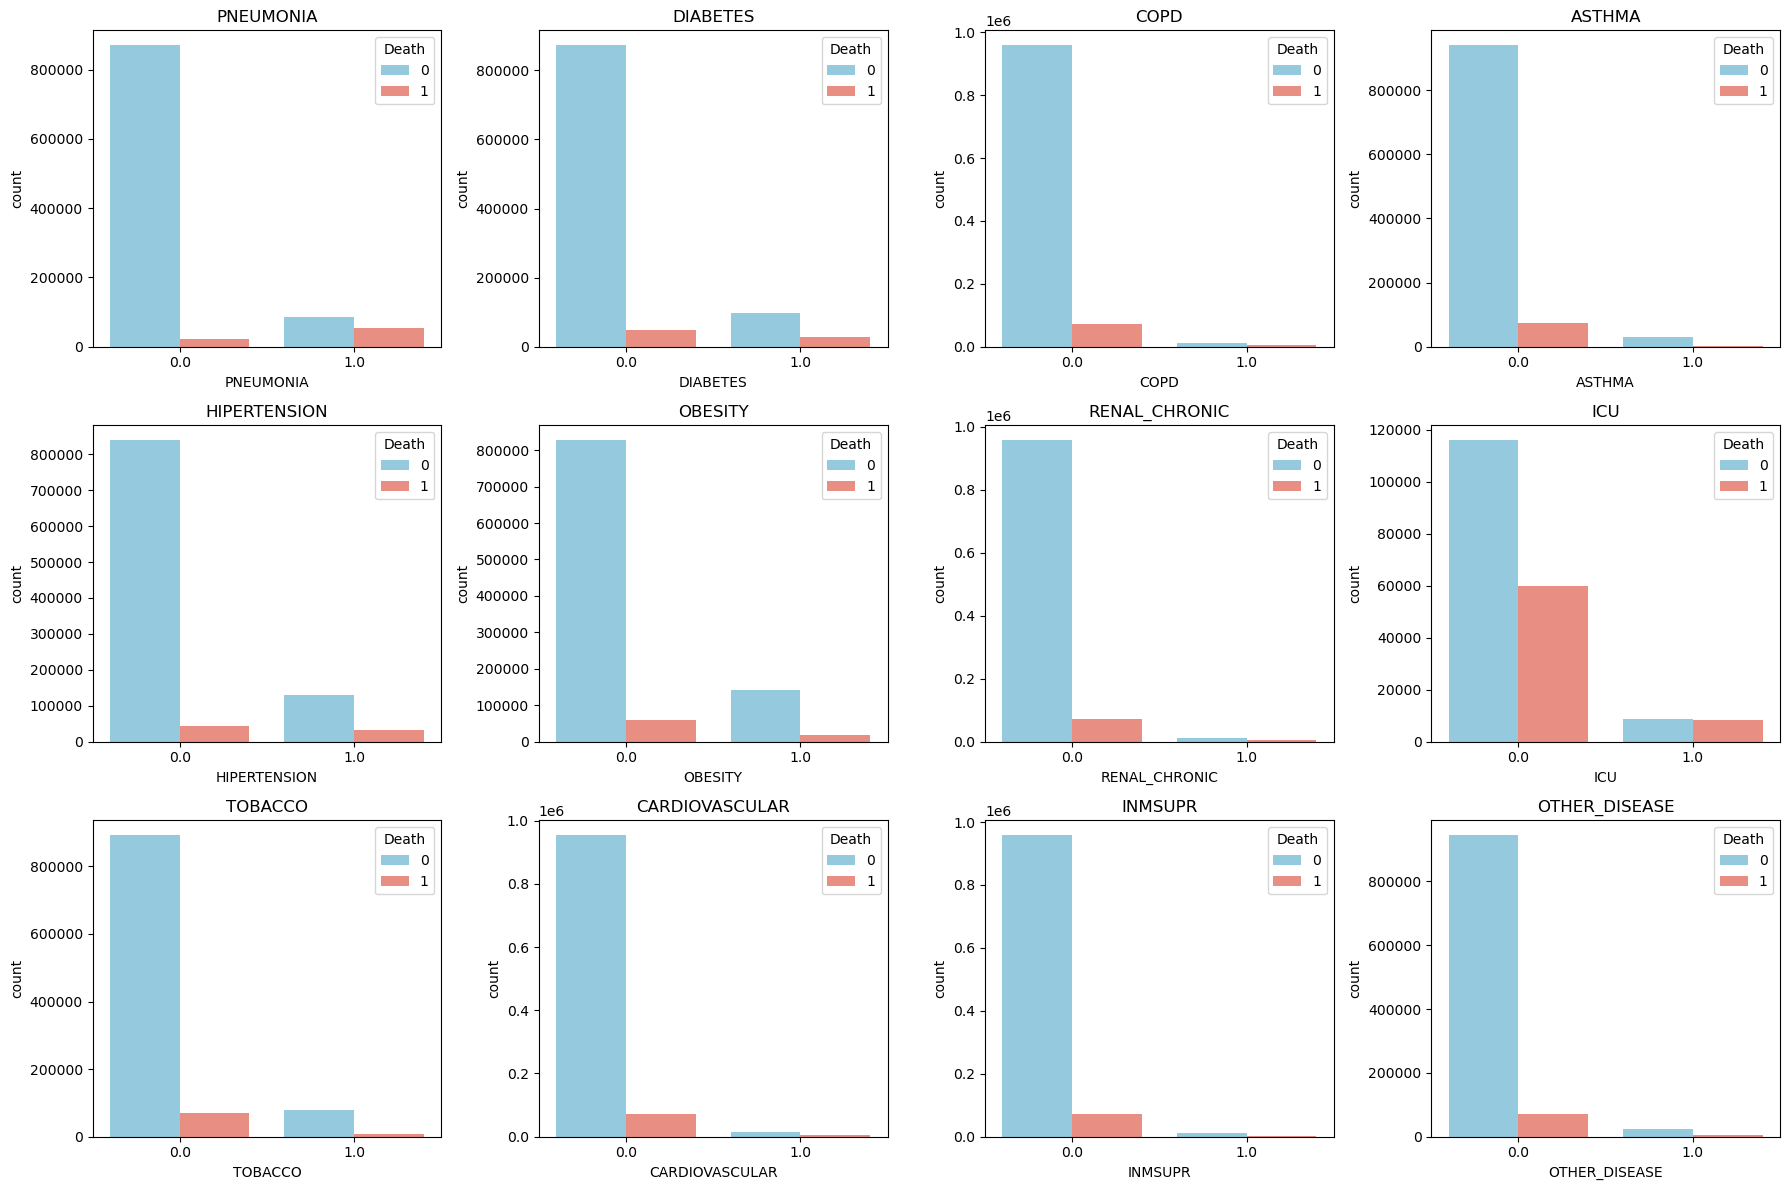

In [59]:
cols = ['PNEUMONIA','DIABETES','COPD','ASTHMA','HIPERTENSION','OBESITY','RENAL_CHRONIC','ICU',
        'TOBACCO','CARDIOVASCULAR','INMSUPR','OTHER_DISEASE']
plt.figure(figsize=(18,12))
for i, col in enumerate(cols, 1):
    plt.subplot(3, 4, i)
    sns.countplot(x=col, hue='Death', data=df, palette=['skyblue', 'salmon'])
    plt.title(col)

plt.tight_layout()
plt.show()

In [60]:
# Conclusion
#  Patients with underlying health conditions such as pneumonia, diabetes, hypertension, obesity, and chronic diseases generally showed a higher number of death cases, indicating that comorbidities increase the risk of severe COVID-19 outcomes.

### Total Diseases vs Death

Death                0      1
TOTAL_DISEASES               
0               613102   7523
1               222794  22569
2                87521  21850
3                34108  15391
4                10551   6945
5                 2587   2023
6                  645    513
7                  157    103
8                   55     15
9                   99      6
10                  14      4


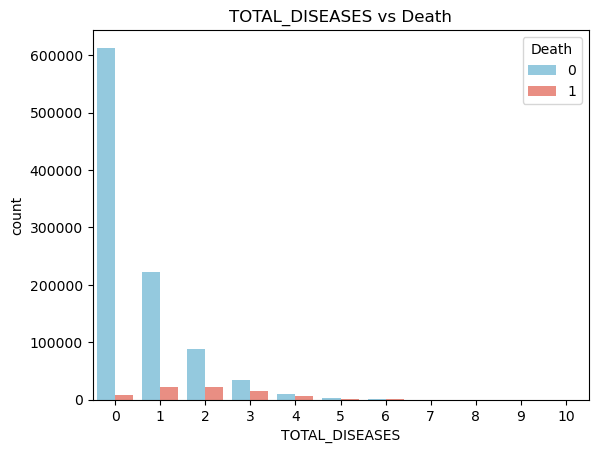

In [61]:
ct = pd.crosstab(df['TOTAL_DISEASES'], df['Death'])
print(ct)
sns.countplot(x='TOTAL_DISEASES',hue='Death',data=df,palette=['skyblue', 'salmon'])

plt.title('TOTAL_DISEASES vs Death')
plt.show()

In [62]:
# Conclusion
# Higher disease count is associated with a greater risk of death, indicating that comorbidities significantly impact patient outcomes.

### Total Diseases  vs Covid Positive

COVID_Positive       0       1
TOTAL_DISEASES                
0               424929  195696
1               142356  103007
2                55354   54017
3                22793   26706
4                 8004    9492
5                 2242    2368
6                  646     512
7                  157     103
8                   45      25
9                   63      42
10                   7      11


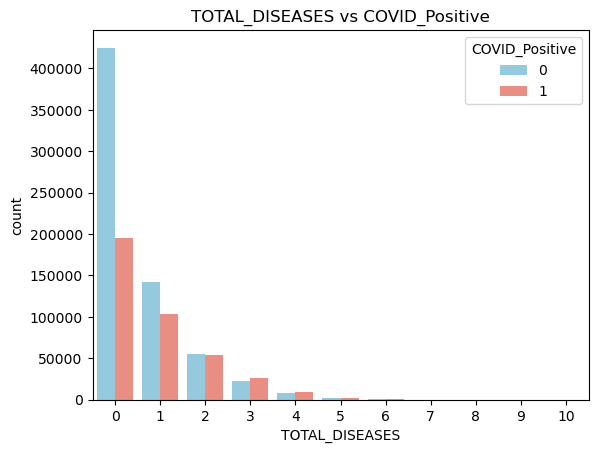

In [63]:
ct = pd.crosstab(df['TOTAL_DISEASES'], df['COVID_Positive'])
print(ct)
sns.countplot(x='TOTAL_DISEASES',hue='COVID_Positive',data=df,palette=['skyblue', 'salmon'])

plt.title('TOTAL_DISEASES vs COVID_Positive')
plt.show()

In [64]:
# Conclusion
# Mortality increases with the number of underlying diseases among COVID-positive patients.

### Total Disease vs Age Group

Age_Group       Infants  Children  Teens  Young Adults  Adults  Seniors
TOTAL_DISEASES                                                         
0                  8342     20083  26016        169086  362265    34833
1                  2779      3596   4192         36129  158728    39939
2                   561       768    742          6503   66242    34555
3                   134       149    197          1373   25528    22118
4                    22        26     39           310    7886     9213
5                     1         3     11            62    1738     2795
6                     1         1      2            12     439      703
7                     1         0      0             5      80      174
8                     0         1      0             9      29       31
9                     0         4      3            20      70        8
10                    1         0      1             2      11        3


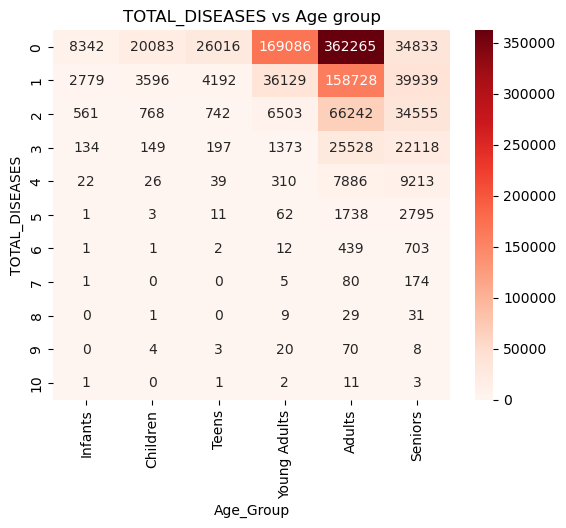

In [65]:
ct = pd.crosstab(df['TOTAL_DISEASES'], df['Age_Group'])
print(ct)
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds')
plt.title('TOTAL_DISEASES vs Age group')
plt.show()

In [66]:
# Conclusion
# The number of underlying diseases tends to increase with age, with adults and seniors showing a higher prevalence of multiple comorbidities.

# Multivariate Analysis

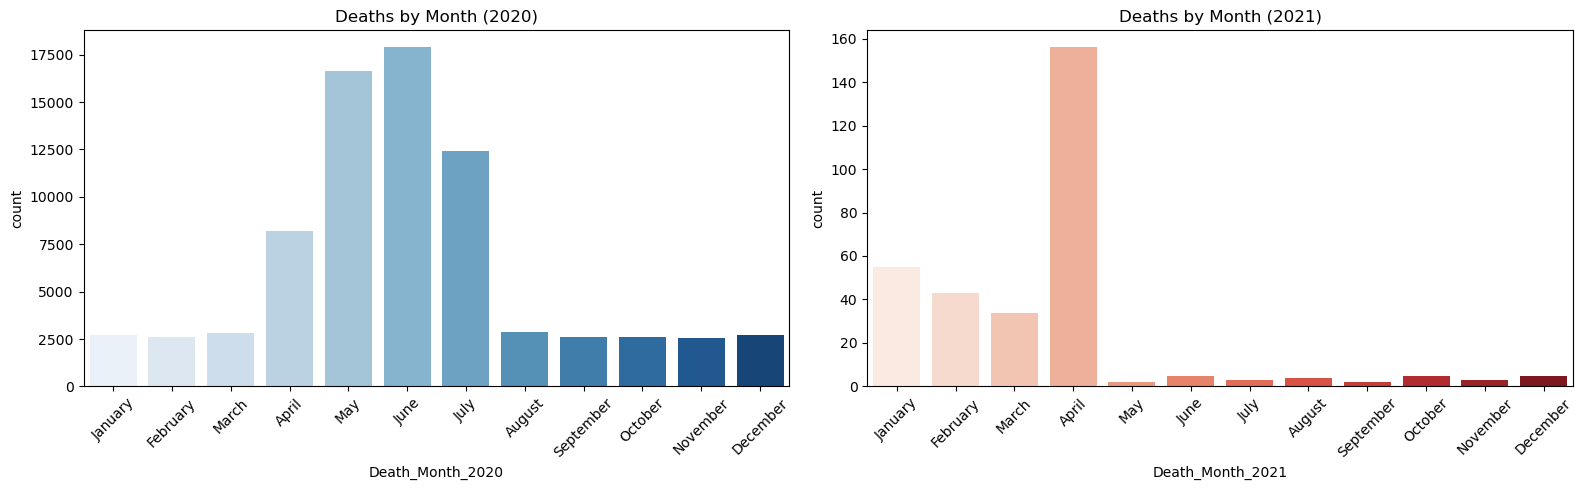

In [67]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

fig, ax = plt.subplots(1, 2, figsize=(16,5))

sns.countplot(x='Death_Month_2020',data=df,order=month_order,palette='Blues',ax=ax[0])

ax[0].set_title('Deaths by Month (2020)')
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x='Death_Month_2021',data=df,order=month_order,palette='Reds',ax=ax[1])

ax[1].set_title('Deaths by Month (2021)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [68]:
#Conclusion:
#The monthly death trend shows fluctuations in COVID-19 fatalities throughout 2020 and 2021, highlighting periods with higher mortality and reflecting the impact of different pandemic waves.

### Age Group vs Gender vs Death

SEX           Female           Male       
Death              0      1       0      1
Age_Group                                 
Infants         5044    185    6349    264
Children       11654    101   12759    117
Teens          15982     97   15014    110
Young Adults  110795    581  101137    998
Adults        304232  10471  285868  22445
Seniors        49955  15967   52844  25606


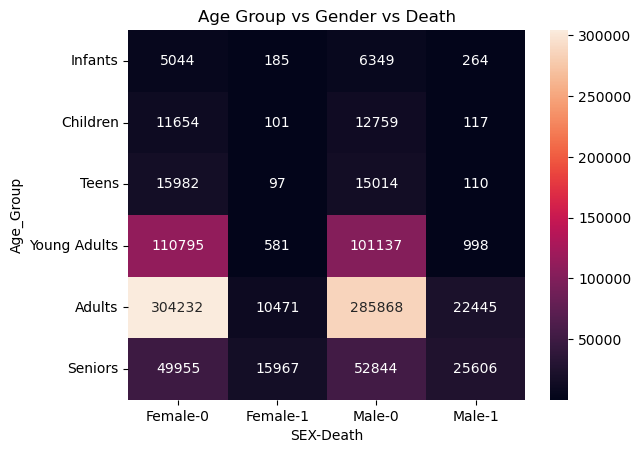

In [69]:
temp = pd.crosstab(
    df['Age_Group'],
    [df['SEX'], df['Death']]
)
print(temp)
sns.heatmap(temp, annot=True, fmt='d')
plt.title('Age Group vs Gender vs Death')
plt.show()

In [70]:
#Conclusion
#The heatmap reveals that death cases are more frequent among older age groups across both genders, highlighting age as a major factor associated with COVID-19 mortality.

### Age Group vs Death vs Covid Positive

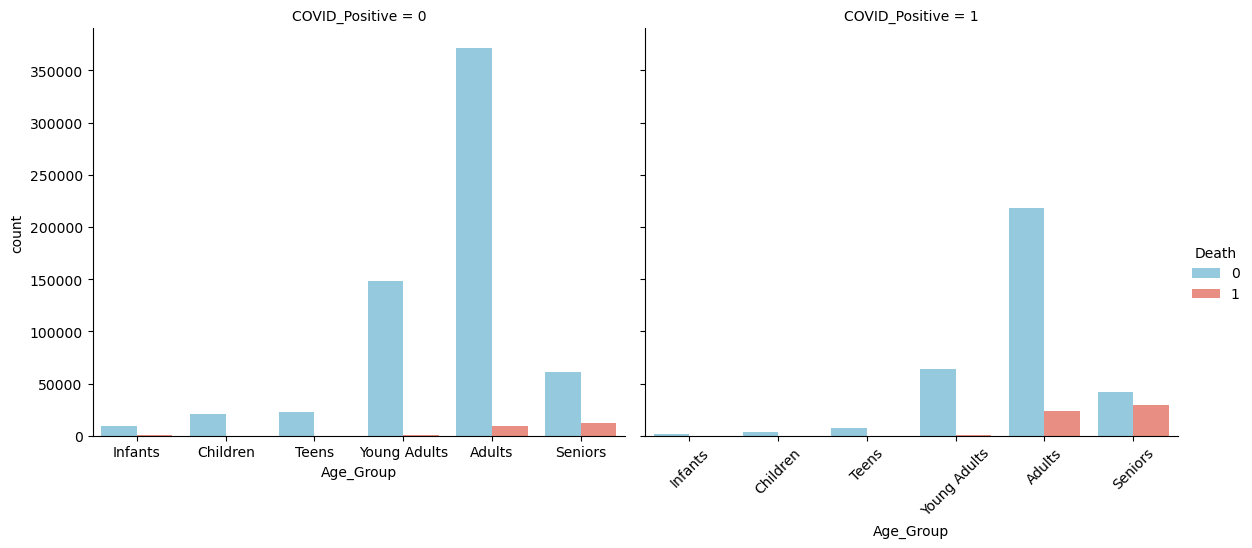

In [71]:
sns.catplot(
    x='Age_Group',
    hue='Death',
    col='COVID_Positive',
    palette=['skyblue', 'salmon'],
    data=df,
    kind='count',
    height=5,
    aspect=1.2
)

plt.xticks(rotation=45)
plt.show()

In [72]:
#Conclusion
#Death cases are more concentrated among COVID-positive patients, particularly in older age groups, indicating a higher mortality risk with increasing age.

### Hospitalized & COVID Status vs Death

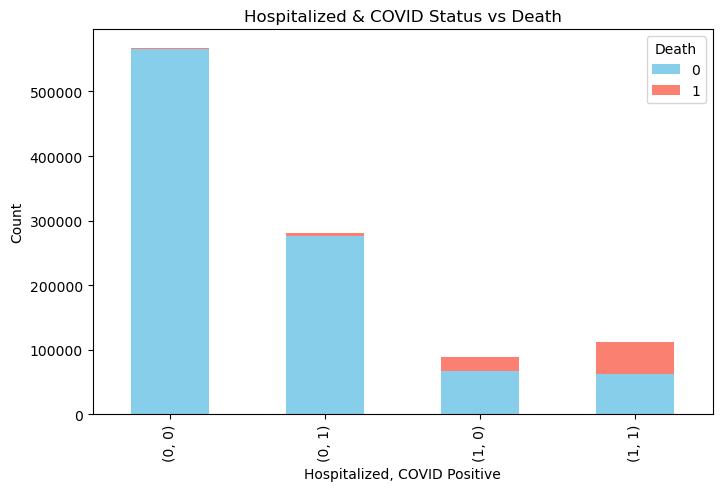

In [73]:
pd.crosstab(
    [df['Hospitalized'], df['COVID_Positive']],
    df['Death']
).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    color=['skyblue', 'salmon']  
)

plt.title('Hospitalized & COVID Status vs Death')
plt.ylabel('Count')
plt.xlabel('Hospitalized, COVID Positive')
plt.show()

In [74]:
#Conclusion
#Hospitalized COVID-positive patients recorded the highest number of death cases, suggesting that severe COVID-19 infections were associated with a greater risk of mortality.

###  Age_Group & Death vs Hospitalized'

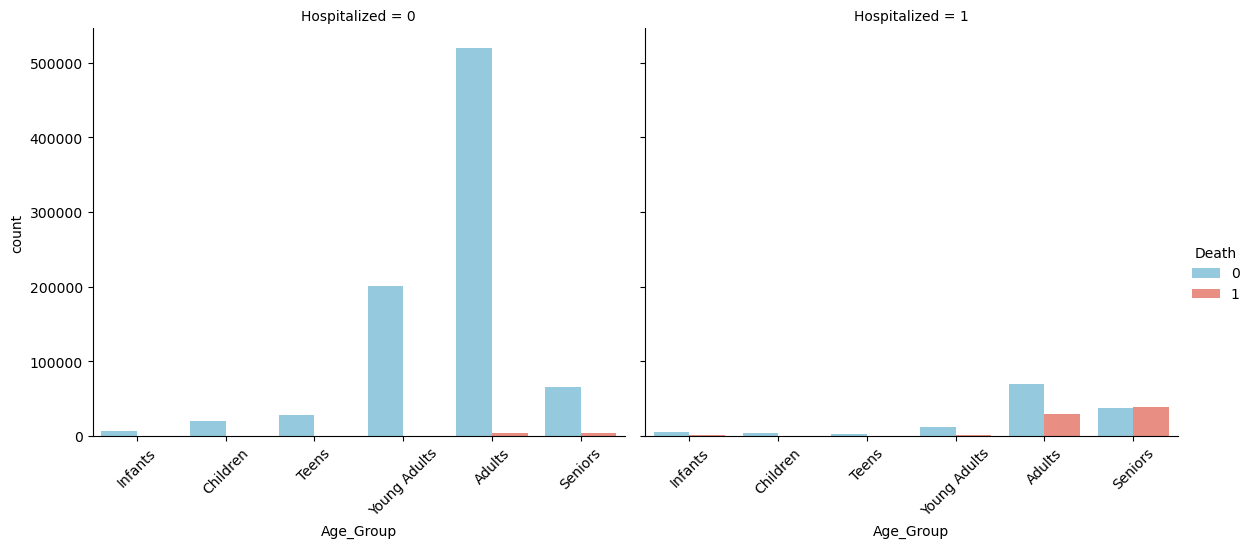

In [75]:
g = sns.catplot(
    x='Age_Group',
    hue='Death',
    col='Hospitalized',
    data=df,
    kind='count',
    height=5,
    aspect=1.2,
    palette=['skyblue', 'salmon']
)

g.set_xticklabels(rotation=45)

plt.show()

In [76]:
#Conclusion
#Death cases are more common among hospitalized patients, especially in older age groups, indicating that hospitalization and increasing age are associated with higher mortality risk.

### ICU & Death & Gender

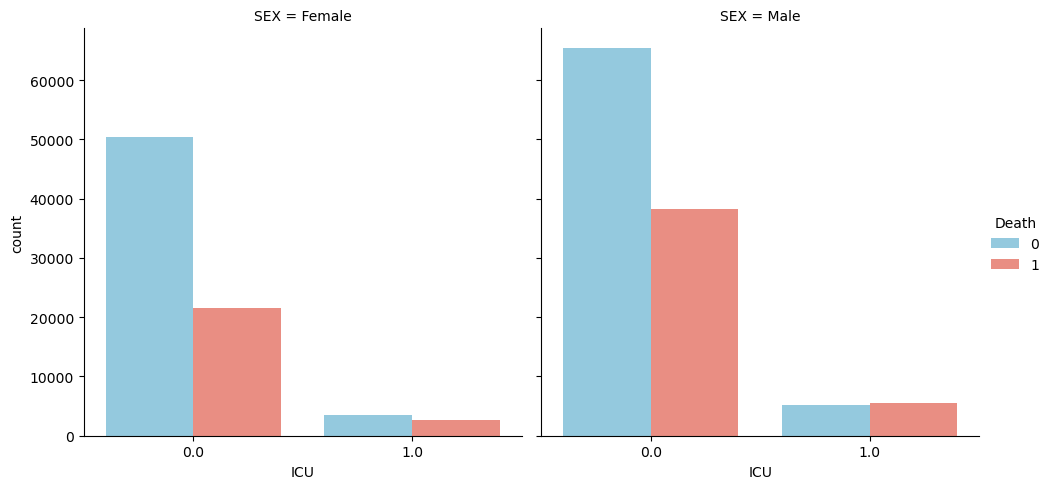

In [77]:
sns.catplot(
    data=df,
    x='ICU',
    hue='Death',
    col='SEX',
    kind='count',
    palette=['skyblue', 'salmon']
)

plt.show()

In [78]:
#Conclusion
#Patients with pneumonia who required ICU care showed a higher number of death cases, indicating that severe respiratory complications increased the risk of mortality.

### Age Group & Death & Disease

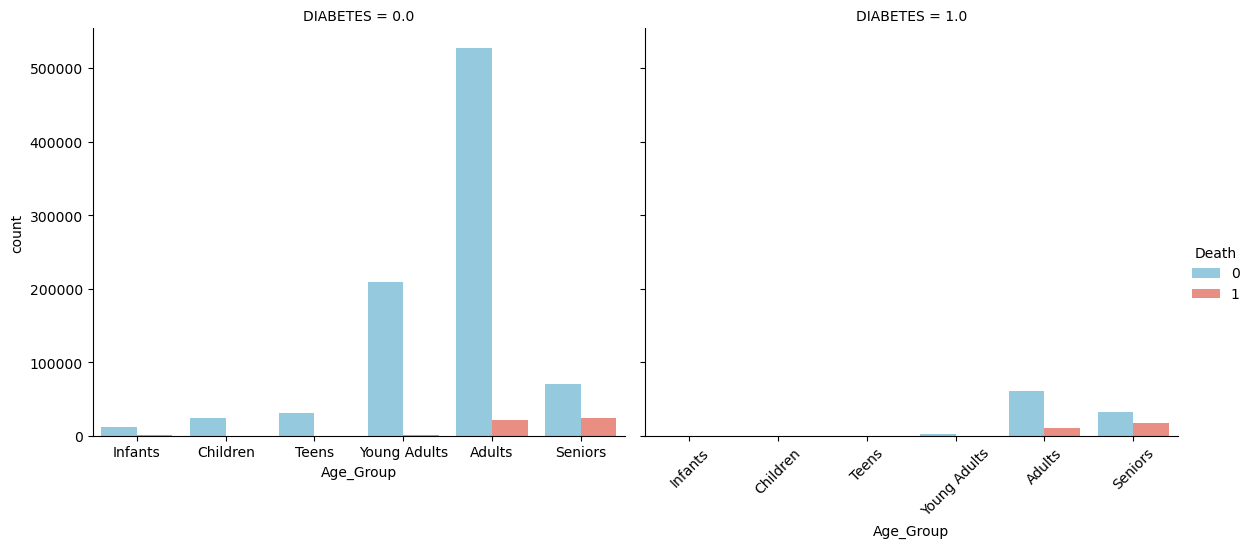

In [79]:
sns.catplot(
    x='Age_Group',
    hue='Death',
    col='DIABETES',
    data=df,
    kind='count',
    height=5,
    aspect=1.2,
    palette=['skyblue', 'salmon']
)

plt.xticks(rotation=45)
plt.show()

In [80]:
#Conclusion
#Death cases are higher among diabetic patients, especially in older age groups, indicating that diabetes combined with age increases the risk of COVID-19 mortality.

### Death Rate% by Age Group & Death

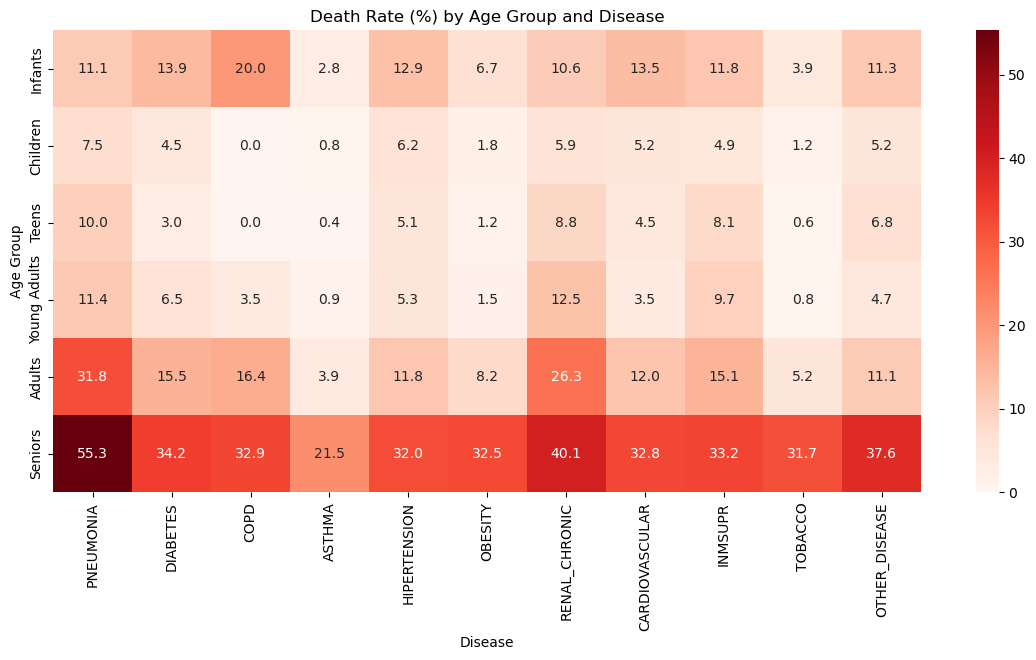

In [81]:
cols = ['PNEUMONIA','DIABETES','COPD','ASTHMA','HIPERTENSION',
        'OBESITY','RENAL_CHRONIC','CARDIOVASCULAR',
        'INMSUPR','TOBACCO','OTHER_DISEASE']

death_heatmap = pd.DataFrame()

for col in cols:death_heatmap[col] = (df[df[col] == 1].groupby('Age_Group')['Death'].mean() * 100)

plt.figure(figsize=(14,6))
sns.heatmap(death_heatmap,annot=True,fmt='.1f',cmap='Reds')

plt.title('Death Rate (%) by Age Group and Disease')
plt.ylabel('Age Group')
plt.xlabel('Disease')
plt.show()

In [82]:
#Conclusion
#Death rates increase with age and are highest among patients with comorbidities such as diabetes, hypertension, pneumonia, and chronic kidney disease. Older patients face the greatest mortality risk.

### TOTAL_DISEASES & Death

In [83]:
disease_cols = [
    'PNEUMONIA','DIABETES','COPD','ASTHMA',
    'HIPERTENSION','OBESITY','RENAL_CHRONIC',
    'CARDIOVASCULAR','INMSUPR','TOBACCO','OTHER_DISEASE'
]

# disease and died
one_disease_death = df[(df['TOTAL_DISEASES'] == 1) &(df['Death'] == 1)]
one_disease_death[disease_cols].sum().sort_values(ascending=False)

PNEUMONIA         15998.0
HIPERTENSION       2170.0
DIABETES           1764.0
TOBACCO            1568.0
OBESITY            1349.0
OTHER_DISEASE       480.0
COPD                235.0
RENAL_CHRONIC       171.0
INMSUPR             171.0
CARDIOVASCULAR      134.0
ASTHMA               97.0
dtype: float64

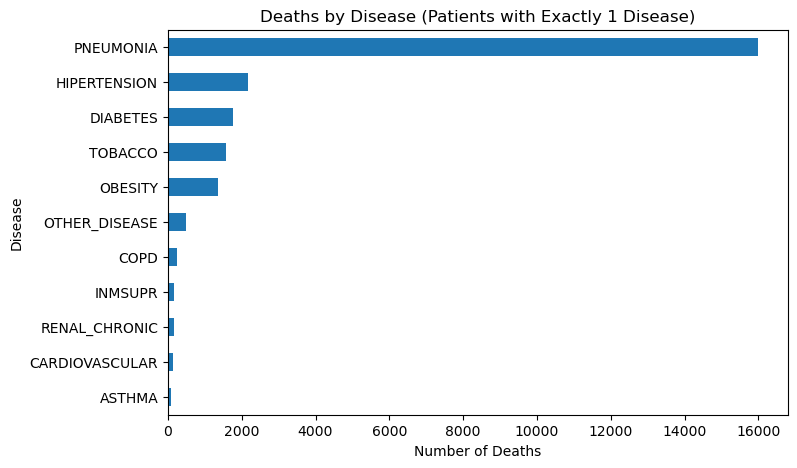

In [84]:
disease_cols = ['PNEUMONIA','DIABETES','COPD','ASTHMA','HIPERTENSION','OBESITY','RENAL_CHRONIC','CARDIOVASCULAR','INMSUPR','TOBACCO','OTHER_DISEASE']
# Exactly 1 disease and died
one_disease_death = df[(df['TOTAL_DISEASES'] == 1) &(df['Death'] == 1)]
one_disease_death[disease_cols].sum().sort_values(ascending=False)
death_counts = one_disease_death[disease_cols].sum().sort_values()
plt.figure(figsize=(8,5))
death_counts.plot(kind='barh')
plt.title('Deaths by Disease (Patients with Exactly 1 Disease)')
plt.xlabel('Number of Deaths')
plt.ylabel('Disease')
plt.show()

In [85]:
# Conclusion 
# Among patients with only one underlying disease, certain conditions contributed to a higher number of deaths. 
# indicating a stronger association with mortality.

# Over all Conclusion 

- Aalyzed 1+ million COVID-19 patient records from Mexico to understand factors affecting mortality and disease severity.
- Age was the strongest risk factor, with patients aged 60+ showing significantly higher death rates.
- Male patients experienced higher mortality compared to female patients.
- Severe conditions such as pneumonia, ICU admission, and intubation were strongly associated with death.
- Patients with comorbidities like diabetes, hypertension, obesity, COPD, and chronic kidney disease faced increased health risks.
-  Hospitalized patients had substantially higher mortality rates than outpatients.
- Mortality trends revealed major COVID-19 waves during 2020 and early 2021.
- he findings highlight the importance of early diagnosis, timely treatment, and focused care for high-risk groups.
- his project demonstrates how Exploratory Data Analysis (EDA) can uncover meaningful healthcare insights and support data-driven decision-making during public health crises.